# Tesis AI
## Ajuste fino y evaluación experimental de YOLOv8n

**Propósito del notebook:** entrenar y evaluar un detector YOLOv8n ajustado al dominio de AgroGuard para las clases `person` y `boat`, conservando evidencia reproducible del proceso de entrenamiento y de las métricas obtenidas.

### Productos generados
1. Auditoría cuantitativa del dataset.
2. Evidencia visual de las anotaciones.
3. Modelo ajustado `best.pt`.
4. Curvas de entrenamiento y validación.
5. Matriz de confusión y curvas Precision-Recall.
6. Métricas finales sobre el conjunto **Test**, no utilizado durante el ajuste.
7. Comparación del modelo YOLOv8n preentrenado en COCO frente al modelo ajustado, usando las **mismas imágenes de Test**.
8. Archivos CSV y figuras exportables para el capítulo de Resultados.

> **Importante:** este notebook corresponde a una prueba de concepto. Las conclusiones deben limitarse a las condiciones y al conjunto experimental evaluado.


## 1. Configuración del entorno de ejecución

Para el entrenamiento se utiliza una GPU de Google Colab. El modelo seleccionado es **YOLOv8n**, inicializado con pesos preentrenados en COCO y posteriormente ajustado mediante transferencia de aprendizaje.

Parámetros principales de esta primera iteración:

| Parámetro | Valor |
|---|---:|
| Modelo inicial | `yolov8n.pt` |
| Tamaño de entrada | 640 px |
| Épocas máximas | 100 |
| Batch | 16 |
| Early stopping | 20 épocas sin mejora |
| Semilla | 42 |
| Clases | `person`, `boat` |

Las 100 épocas representan un **máximo**, no la duración obligatoria. El criterio `patience=20` permite detener el entrenamiento si el desempeño de validación deja de mejorar.


In [ ]:
!nvidia-smi


Tue Aug 25 01:03:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics==8.4.117 pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.4 MB/s eta 0:00:00


In [ ]:
import sys
import os
import json
import random
import shutil
import zipfile
from pathlib import Path

import cv2
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), (
    "No se detectó GPU CUDA. En Colab selecciona: "
    "Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU."
)

DEVICE = 0

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


## 2. Persistencia de resultados en Google Drive

Los resultados se guardan en Drive para evitar perderlos si la sesión de Colab se reinicia.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/AgroGuard_AI")
DATASETS_DIR = DRIVE_ROOT / "datasets"
RESULTS_DIR = DRIVE_ROOT / "resultados_yolov8n_v1"
FIGURES_DIR = RESULTS_DIR / "figuras_tesis"
TABLES_DIR = RESULTS_DIR / "tablas_tesis"

for directory in [DATASETS_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Directorio de resultados:", RESULTS_DIR)


Mounted at /content/drive
Directorio de resultados: /content/drive/MyDrive/AgroGuard_AI/resultados_yolov8n_v1


In [ ]:
environment_info = {
    "python": sys.version,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}

try:
    import ultralytics
    environment_info["ultralytics"] = ultralytics.__version__
except Exception:
    pass

with open(RESULTS_DIR / "environment.json", "w", encoding="utf-8") as f:
    json.dump(environment_info, f, indent=2, ensure_ascii=False)

environment_info


## 3. Descarga de la versión congelada del dataset desde Roboflow

Se descarga exactamente la versión del dataset que será empleada en el experimento. El enlace se obtiene desde Colab Secrets para evitar exponer la credencial.

La separación `train / valid / test` debe haber sido realizada previamente por **video o sesión de origen**, evitando que fotogramas del mismo video aparezcan en más de un subconjunto.


In [ ]:
from google.colab import userdata
import requests

DATASET_ZIP = Path("/content/agroguard_dataset.zip")
DATASET_DIR = Path("/content/agroguard_dataset")

dataset_url = userdata.get("ROBOFLOW_DATASET_URL")

if not dataset_url:
    raise RuntimeError(
        "No se encontró el secreto ROBOFLOW_DATASET_URL. "
        "Créalo en el panel Secrets de Google Colab."
    )

response = requests.get(dataset_url, timeout=180)
response.raise_for_status()
DATASET_ZIP.write_bytes(response.content)

if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

DATASET_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
    zf.extractall(DATASET_DIR)

yaml_files = list(DATASET_DIR.rglob("data.yaml"))

if len(yaml_files) != 1:
    raise RuntimeError(
        f"Se esperaba un único data.yaml y se encontraron {len(yaml_files)}: {yaml_files}"
    )

DATA_YAML = yaml_files[0]

print("Dataset extraído en:", DATASET_DIR)
print("data.yaml:", DATA_YAML)


Dataset extraído en: /content/agroguard_dataset
data.yaml: /content/agroguard_dataset/data.yaml


In [ ]:
with open(DATA_YAML, "r", encoding="utf-8") as f:
    dataset_cfg = yaml.safe_load(f)

dataset_cfg


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 2,
 'names': ['boat', 'person'],
 'roboflow': {'workspace': 'braulios-workspace-sgbpc',
  'project': 'agroguard',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/braulios-workspace-sgbpc/agroguard/dataset/1'}}

## 4. Auditoría del dataset

Antes del entrenamiento se cuantifican:

- número de imágenes por subconjunto;
- imágenes sin anotaciones (negativos);
- número de instancias por clase;
- distribución de clases entre Train, Validation y Test.

Esta auditoría permite verificar que la información utilizada en el entrenamiento corresponde a la versión documentada del dataset.


In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def normalize_names(names):
    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}
    return {i: str(name) for i, name in enumerate(names)}

CLASS_NAMES = normalize_names(dataset_cfg["names"])
CLASS_NAMES


{0: 'boat', 1: 'person'}

In [ ]:
# ============================================================
# FUNCIONES PARA AUDITAR EL DATASET
# ============================================================


def resolve_split_images(
    data_yaml,
    split_key
):
    """
    Localiza la carpeta de imágenes correspondiente
    a Train, Validation o Test.

    Para el dataset exportado desde Roboflow se utiliza
    la estructura real encontrada dentro de DATASET_DIR.
    """

    # --------------------------------------------------------
    # Correspondencia entre nombre lógico y carpeta real
    # --------------------------------------------------------

    split_folders = {
        "train": "train",
        "val": "valid",
        "test": "test"
    }


    if split_key not in split_folders:

        raise ValueError(
            f"Split no reconocido: {split_key}"
        )


    folder_name = split_folders[
        split_key
    ]


    # --------------------------------------------------------
    # Ruta esperada dentro del dataset extraído
    # --------------------------------------------------------

    images_dir = (
        DATASET_DIR
        / folder_name
        / "images"
    )


    if images_dir.exists():

        return images_dir.resolve()


    # --------------------------------------------------------
    # Si no existe, mostrar error claro
    # --------------------------------------------------------

    raise RuntimeError(
        f"No se encontró la carpeta de imágenes "
        f"para el split '{split_key}'.\n"
        f"Ruta esperada:\n{images_dir}"
    )


# ============================================================
# OBTENER ARCHIVO DE ETIQUETA DE UNA IMAGEN
# ============================================================

def corresponding_label_path(
    image_path
):
    """
    Convierte una ruta como:

    /train/images/imagen.jpg

    en:

    /train/labels/imagen.txt
    """

    return (
        image_path
        .parent
        .parent
        / "labels"
        / f"{image_path.stem}.txt"
    )


# ============================================================
# AUDITAR UN SPLIT
# ============================================================

def audit_split(
    images_dir,
    class_names
):

    # --------------------------------------------------------
    # Buscar todas las imágenes
    # --------------------------------------------------------

    images = sorted(
        p
        for p in images_dir.rglob("*")
        if p.suffix.lower()
        in IMAGE_EXTENSIONS
    )


    # --------------------------------------------------------
    # Inicializar contador de instancias por clase
    # --------------------------------------------------------

    instance_counts = {
        cid: 0
        for cid
        in class_names
    }


    negatives = 0


    # --------------------------------------------------------
    # Revisar cada imagen
    # --------------------------------------------------------

    for img in images:

        label_path = (
            corresponding_label_path(
                img
            )
        )


        # ====================================================
        # CASO 1:
        # No existe archivo .txt
        # Se considera imagen negativa
        # ====================================================

        if not label_path.exists():

            negatives += 1

            continue


        # ====================================================
        # LEER ETIQUETA
        # ====================================================

        content = (
            label_path
            .read_text(
                encoding="utf-8"
            )
            .strip()
        )


        # ====================================================
        # CASO 2:
        # Archivo .txt existe pero está vacío
        # También es imagen negativa
        # ====================================================

        if not content:

            negatives += 1

            continue


        # ====================================================
        # CONTAR INSTANCIAS
        # ====================================================

        for line in content.splitlines():

            parts = line.split()


            if not parts:

                continue


            class_id = int(
                float(
                    parts[0]
                )
            )


            instance_counts[
                class_id
            ] = (
                instance_counts.get(
                    class_id,
                    0
                )
                + 1
            )


    # --------------------------------------------------------
    # RESULTADO
    # --------------------------------------------------------

    return {

        "images":
            len(images),

        "negatives":
            negatives,

        "instances":
            instance_counts
    }


# ============================================================
# DEFINICIÓN DE SPLITS
# ============================================================

SPLIT_KEYS = {

    "Train":
        "train",

    "Validation":
        "val",

    "Test":
        "test"
}


# ============================================================
# EJECUTAR AUDITORÍA
# ============================================================

audit = {}


for (
    display_name,
    split_key
) in SPLIT_KEYS.items():


    images_dir = (
        resolve_split_images(
            DATA_YAML,
            split_key
        )
    )


    print(
        f"{display_name}: "
        f"{images_dir}"
    )


    audit[
        display_name
    ] = audit_split(
        images_dir,
        CLASS_NAMES
    )


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

audit

Train: /content/agroguard_dataset/train/images
Validation: /content/agroguard_dataset/valid/images
Test: /content/agroguard_dataset/test/images


{'Train': {'images': 760, 'negatives': 73, 'instances': {0: 501, 1: 1182}},
 'Validation': {'images': 127, 'negatives': 0, 'instances': {0: 186, 1: 201}},
 'Test': {'images': 110, 'negatives': 0, 'instances': {0: 235, 1: 72}}}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
split_rows = []

for split_name, info in audit.items():
    row = {
        "Split": split_name,
        "Imágenes": info["images"],
        "Negativas": info["negatives"],
    }
    for cid, cname in CLASS_NAMES.items():
        row[f"Instancias_{cname}"] = info["instances"].get(cid, 0)
    split_rows.append(row)

df_split = pd.DataFrame(split_rows)
display(df_split)

df_split.to_csv(
    TABLES_DIR / "distribucion_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Total de imágenes:", int(df_split["Imágenes"].sum()))
print("Total de negativas:", int(df_split["Negativas"].sum()))


,Split,Imágenes,Negativas,Instancias_boat,Instancias_person
0,Train,760,73,501,1182
1,Validation,127,0,186,201
2,Test,110,0,235,72


Total de imágenes: 997
Total de negativas: 73


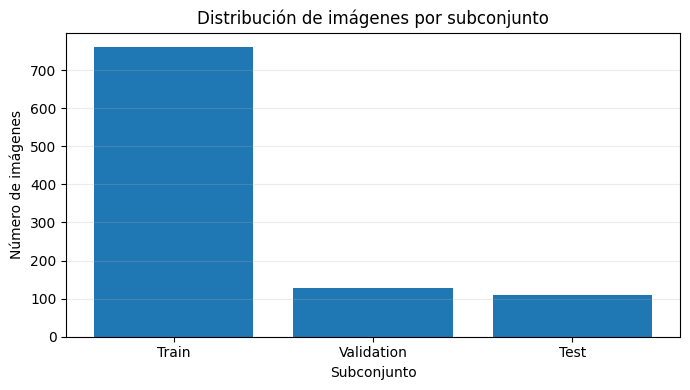

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_split["Split"], df_split["Imágenes"])
ax.set_title("Distribución de imágenes por subconjunto")
ax.set_xlabel("Subconjunto")
ax.set_ylabel("Número de imágenes")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()

fig.savefig(FIGURES_DIR / "01_distribucion_splits.png", dpi=300, bbox_inches="tight")
plt.show()


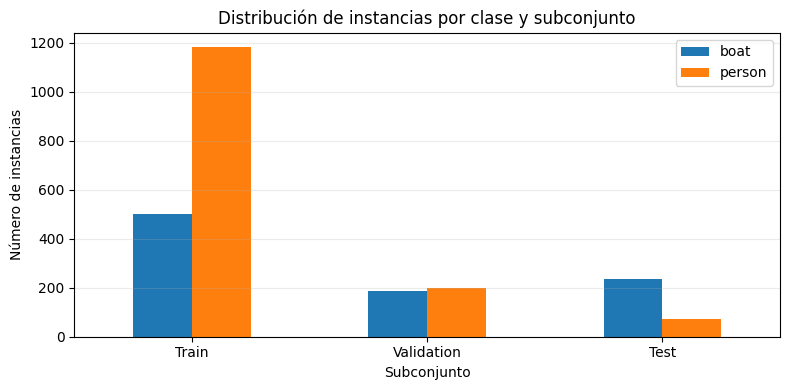

In [ ]:
instance_cols = [c for c in df_split.columns if c.startswith("Instancias_")]

plot_df = df_split.set_index("Split")[instance_cols]
plot_df.columns = [c.replace("Instancias_", "") for c in plot_df.columns]

ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribución de instancias por clase y subconjunto")
ax.set_xlabel("Subconjunto")
ax.set_ylabel("Número de instancias")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "02_instancias_por_clase.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretación de la auditoría

La auditoría no evalúa todavía el rendimiento del modelo. Su función es documentar la composición del conjunto experimental y detectar problemas antes del entrenamiento.

Se debe comprobar especialmente que:

1. `person` y `boat` estén representadas en Train, Validation y Test.
2. Las imágenes negativas se conserven sin crear una clase `background`.
3. El conjunto Test permanezca completamente reservado para la evaluación final.


## 5. Inspección visual de anotaciones

Se muestran ejemplos aleatorios para verificar visualmente la correspondencia entre imágenes y bounding boxes.


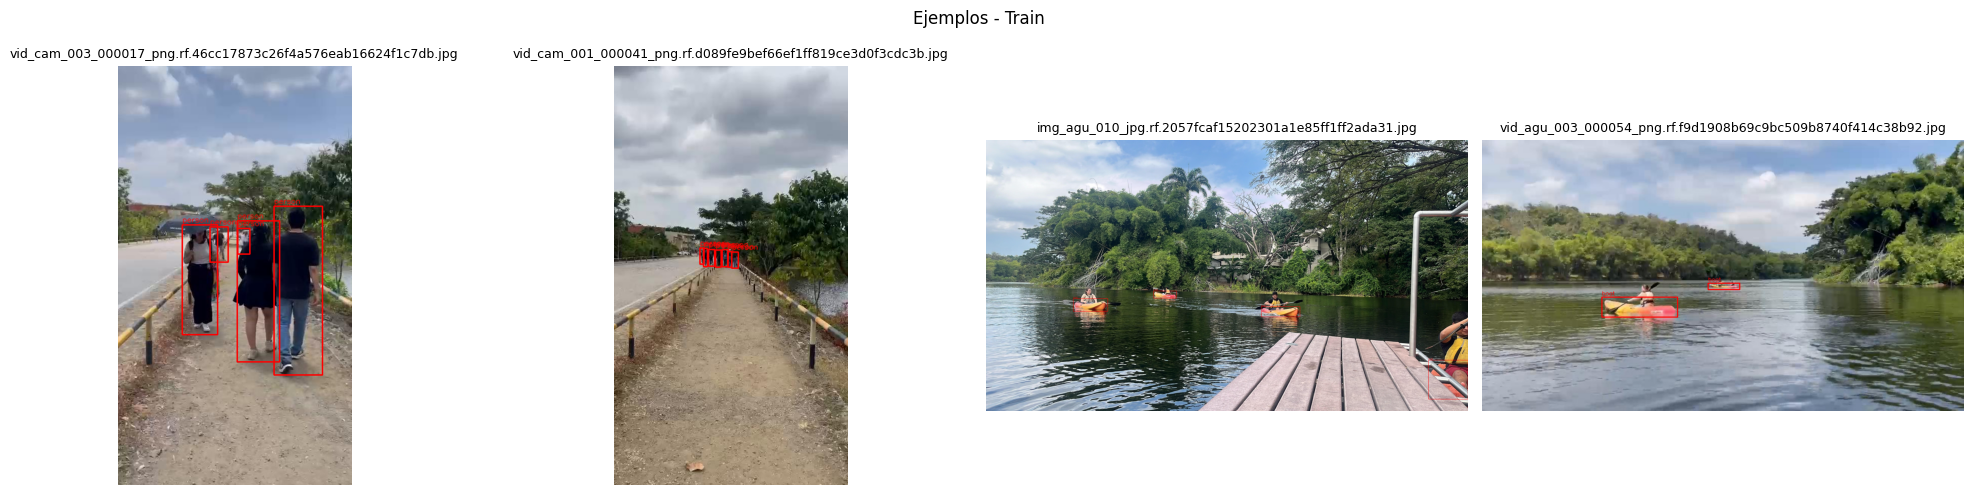

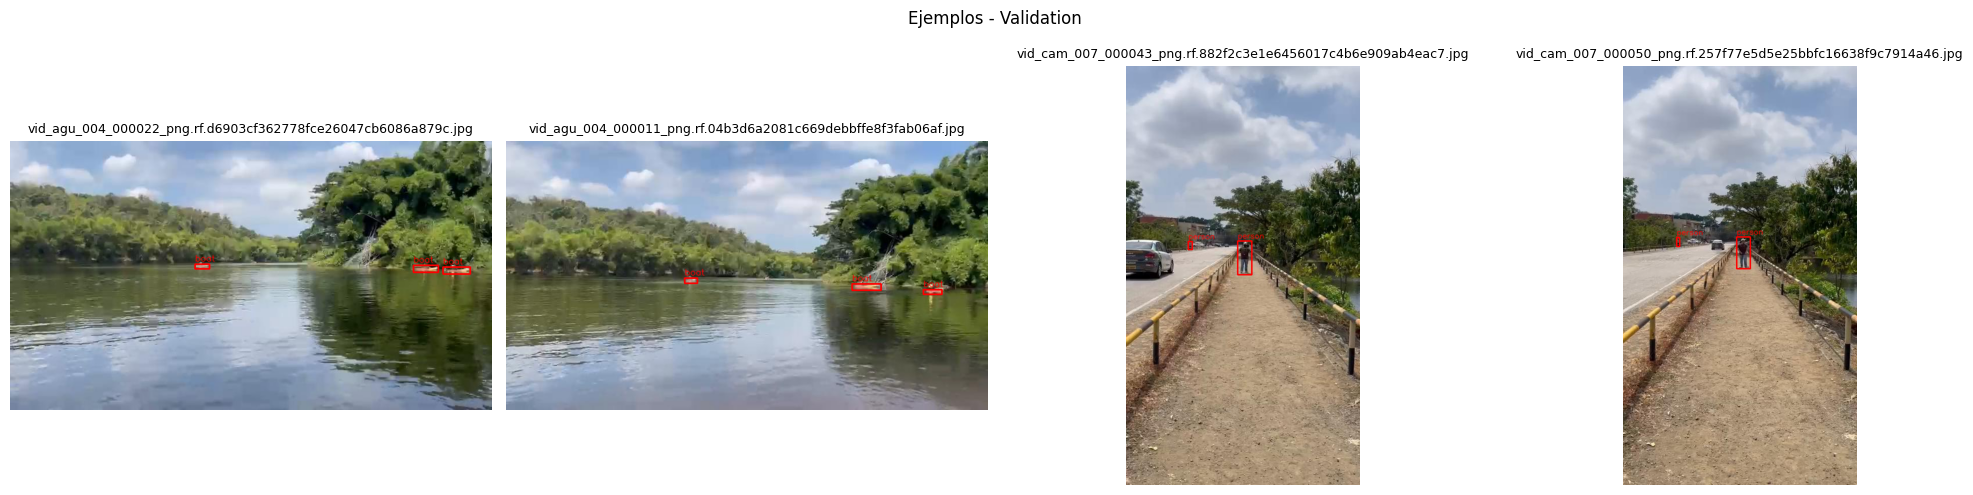

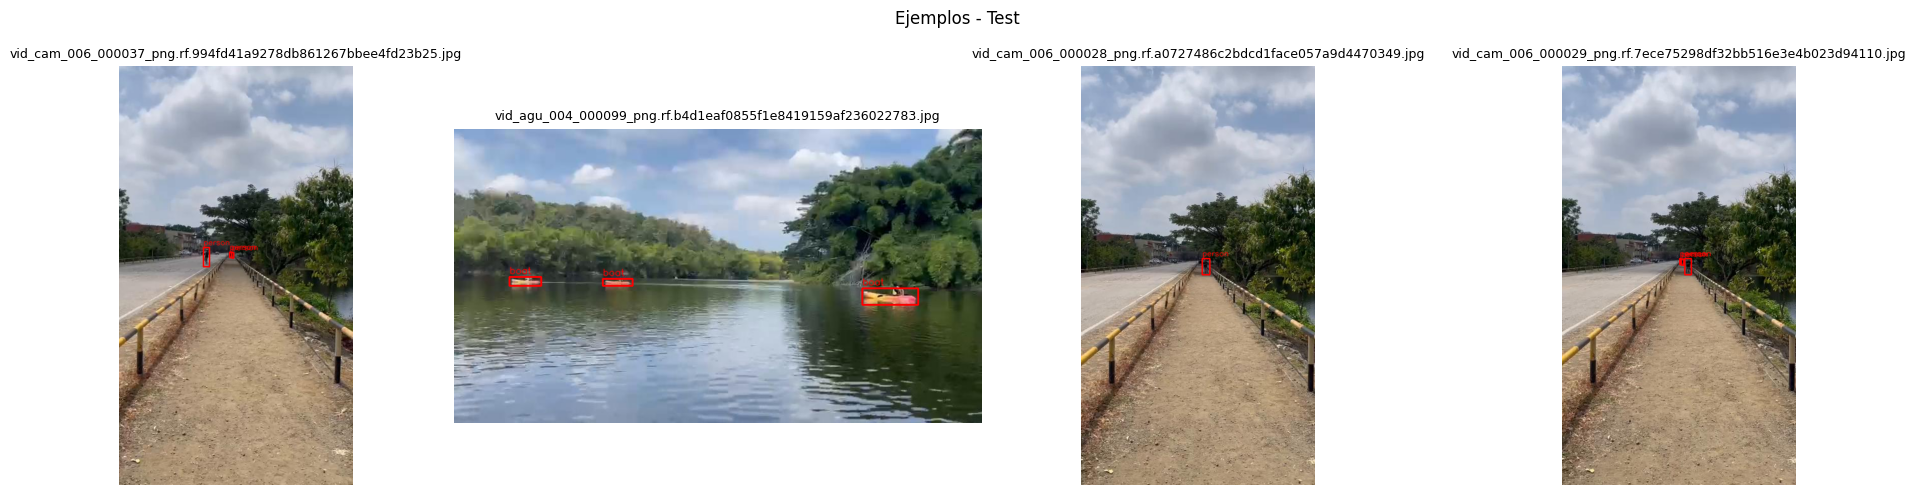

In [ ]:
def read_yolo_boxes(image_path):
    label_path = corresponding_label_path(image_path)
    boxes = []

    if not label_path.exists():
        return boxes

    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return boxes

    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]

    for line in text.splitlines():
        cls, xc, yc, bw, bh = map(float, line.split()[:5])
        cls = int(cls)

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        boxes.append((cls, x1, y1, x2, y2))

    return boxes


def show_random_annotations(images_dir, title, n=4):
    images = [
        p for p in images_dir.rglob("*")
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected = random.sample(images, min(n, len(images)))

    fig, axes = plt.subplots(1, len(selected), figsize=(5 * len(selected), 5))
    if len(selected) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, selected):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        for cls, x1, y1, x2, y2 in read_yolo_boxes(image_path):
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                image,
                CLASS_NAMES.get(cls, str(cls)),
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                1,
                cv2.LINE_AA,
            )

        ax.imshow(image)
        ax.set_title(image_path.name, fontsize=9)
        ax.axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


for split_name, split_key in SPLIT_KEYS.items():
    show_random_annotations(
        resolve_split_images(DATA_YAML, split_key),
        f"Ejemplos - {split_name}",
        n=4,
    )


## 6. Entrenamiento por transferencia de aprendizaje

Se utiliza `yolov8n.pt`, previamente entrenado en COCO. El entrenamiento ajusta sus parámetros al dominio experimental de AgroGuard.

- `imgsz=640`: compromiso inicial entre detalle visual y costo computacional.
- `epochs=100`: máximo de épocas.
- `patience=20`: detención temprana si Validation deja de mejorar.
- `seed=42` y `deterministic=True`: favorecen la reproducibilidad.
- `plots=True`: conserva curvas y matrices de evaluación.

El conjunto Test no interviene en la selección del mejor checkpoint.


In [ ]:
TRAIN_RUN_NAME = "finetuning_yolov8n_agroguard_v1"

model = YOLO("yolov8n.pt")

train_results = model.train(
    data=str(DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    device=DEVICE,
    workers=2,
    pretrained=True,
    optimizer="auto",
    seed=SEED,
    deterministic=True,
    amp=True,
    plots=True,
    save=True,
    project=str(RESULTS_DIR),
    name=TRAIN_RUN_NAME,
    exist_ok=True,
    verbose=True,
)

TRAIN_RUN_DIR = RESULTS_DIR / TRAIN_RUN_NAME
BEST_MODEL = TRAIN_RUN_DIR / "weights" / "best.pt"
LAST_MODEL = TRAIN_RUN_DIR / "weights" / "last.pt"

print("Mejor modelo:", BEST_MODEL)
print("Último modelo:", LAST_MODEL)

assert BEST_MODEL.exists(), "No se encontró best.pt."


New https://pypi.org/project/ultralytics/8.4.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.117 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/agroguard_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

## 7. Análisis del proceso de entrenamiento

Las curvas permiten estudiar la evolución de las pérdidas y de las métricas sobre Validation.

- reducción coherente de pérdidas de entrenamiento y validación: aprendizaje estable;
- aumento de mAP50 y mAP50-95: mejor desempeño de detección;
- reducción continua de pérdida de entrenamiento con deterioro de validación: posible sobreajuste.

`best.pt` representa el checkpoint seleccionado durante el entrenamiento y no necesariamente la última época.


In [ ]:
RESULTS_CSV = TRAIN_RUN_DIR / "results.csv"

df_results = pd.read_csv(RESULTS_CSV)
df_results.columns = [c.strip() for c in df_results.columns]

display(df_results.tail())

df_results.to_csv(
    TABLES_DIR / "historial_entrenamiento.csv",
    index=False,
    encoding="utf-8-sig"
)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
61,62,874.552,1.23523,0.63841,0.93979,0.76567,0.69817,0.74654,0.31263,1.93374,0.90369,0.94957,0.000660,0.000660,0.000660
62,63,889.118,1.22564,0.62302,0.93026,0.77484,0.64360,0.69053,0.29162,1.94285,0.98472,0.94348,0.000644,0.000644,0.000644
63,64,903.424,1.22647,0.64143,0.93387,0.80432,0.66538,0.73662,0.31238,1.88888,1.03242,0.93037,0.000627,0.000627,0.000627
64,65,917.592,1.21624,0.62413,0.93500,0.84903,0.62955,0.71313,0.29820,1.93279,1.03129,0.94303,0.000611,0.000611,0.000611
65,66,931.946,1.19070,0.61812,0.92511,0.83349,0.62229,0.69305,0.29083,1.96530,1.07969,0.94608,0.000594,0.000594,0.000594


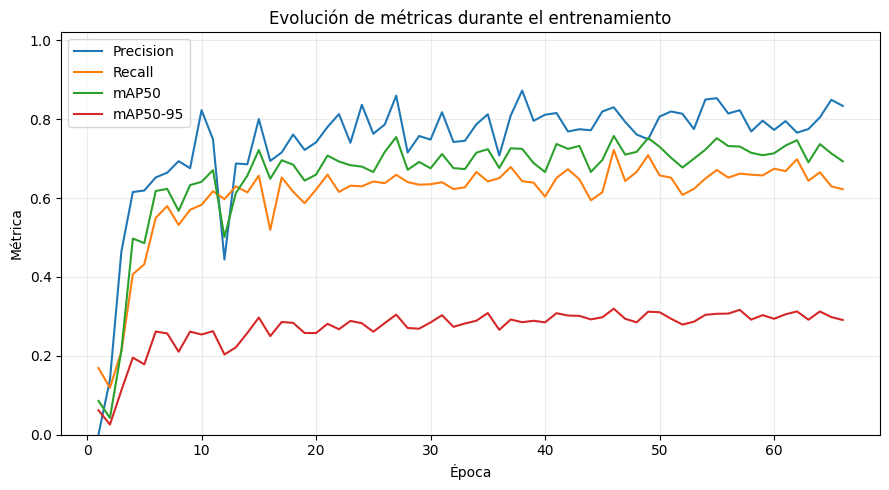

In [ ]:
def find_col(df, *candidates):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    for col in df.columns:
        for candidate in candidates:
            if candidate.lower() in col.lower():
                return col
    return None

epoch_col = find_col(df_results, "epoch")

metric_cols = {
    "Precision": find_col(df_results, "metrics/precision(B)", "precision"),
    "Recall": find_col(df_results, "metrics/recall(B)", "recall"),
    "mAP50": find_col(df_results, "metrics/mAP50(B)", "mAP50"),
    "mAP50-95": find_col(df_results, "metrics/mAP50-95(B)", "mAP50-95"),
}

fig, ax = plt.subplots(figsize=(9, 5))

for label, col in metric_cols.items():
    if col is not None:
        ax.plot(df_results[epoch_col], df_results[col], label=label)

ax.set_title("Evolución de métricas durante el entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

fig.savefig(FIGURES_DIR / "03_metricas_por_epoca.png", dpi=300, bbox_inches="tight")
plt.show()


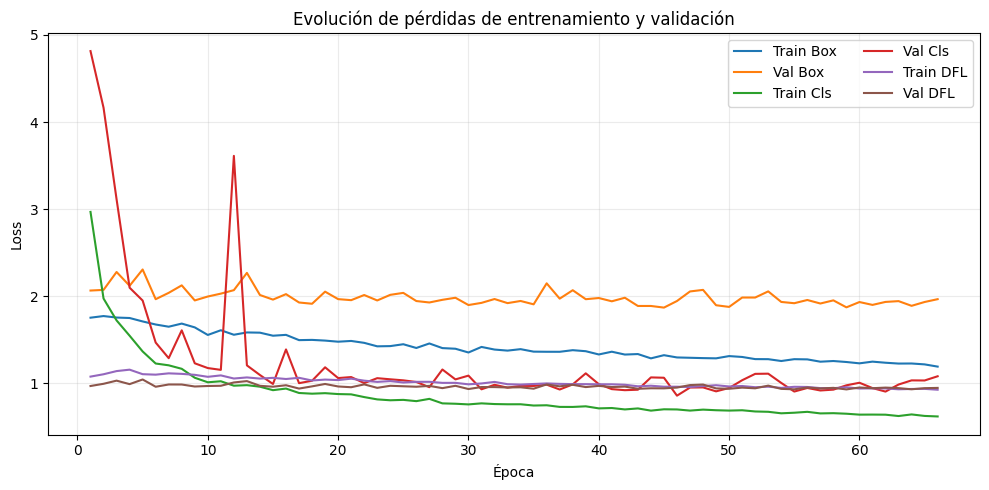

In [ ]:
loss_candidates = {
    "Train Box": find_col(df_results, "train/box_loss"),
    "Val Box": find_col(df_results, "val/box_loss"),
    "Train Cls": find_col(df_results, "train/cls_loss"),
    "Val Cls": find_col(df_results, "val/cls_loss"),
    "Train DFL": find_col(df_results, "train/dfl_loss"),
    "Val DFL": find_col(df_results, "val/dfl_loss"),
}

fig, ax = plt.subplots(figsize=(10, 5))

for label, col in loss_candidates.items():
    if col is not None:
        ax.plot(df_results[epoch_col], df_results[col], label=label)

ax.set_title("Evolución de pérdidas de entrenamiento y validación")
ax.set_xlabel("Época")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()

fig.savefig(FIGURES_DIR / "04_losses_entrenamiento_validacion.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Evaluación final de `best.pt` sobre Test

El conjunto Test se utiliza después de finalizar el ajuste.

Se reportan:

- **Precision (P)**;
- **Recall (R)**;
- **F1**;
- **mAP50**;
- **mAP50-95**.

En una aplicación de seguridad, Recall merece especial atención porque un falso negativo representa un objeto de interés que no fue detectado.


In [ ]:
best_model = YOLO(str(BEST_MODEL))

test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=DEVICE,
    plots=True,
    project=str(RESULTS_DIR),
    name="test_best_agroguard",
    exist_ok=True,
    verbose=True,
)

print("Precision media:", test_metrics.box.mp)
print("Recall medio:", test_metrics.box.mr)
print("mAP50:", test_metrics.box.map50)
print("mAP50-95:", test_metrics.box.map)
print("Velocidad (ms/imagen):", test_metrics.speed)


Ultralytics 8.4.117 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1750.3±532.1 MB/s, size: 49.7 KB)
val: Scanning /content/agroguard_dataset/test/labels... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 2.1Kit/s 0.1s
val: New cache created: /content/agroguard_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.8it/s 2.5s
                   all        110        307      0.973      0.749      0.798      0.395
                  boat         66        235      0.967      0.872      0.928      0.449
                person         44         72      0.978      0.625      0.668      0.341
Speed: 3.2ms preprocess, 4.1ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/drive/MyDrive/AgroGuard_AI/resultados_yolov8n_v1/

In [ ]:
best_summary = pd.DataFrame(test_metrics.summary(decimals=5))

display(best_summary)

best_summary.to_csv(
    TABLES_DIR / "metricas_test_best_por_clase.csv",
    index=False,
    encoding="utf-8-sig"
)

global_best = pd.DataFrame([{
    "Modelo": "YOLOv8n ajustado AgroGuard",
    "Precision_media": test_metrics.box.mp,
    "Recall_medio": test_metrics.box.mr,
    "mAP50": test_metrics.box.map50,
    "mAP50-95": test_metrics.box.map,
    "Preprocess_ms_img": test_metrics.speed.get("preprocess"),
    "Inference_ms_img": test_metrics.speed.get("inference"),
    "Postprocess_ms_img": test_metrics.speed.get("postprocess"),
}])

display(global_best)

global_best.to_csv(
    TABLES_DIR / "metricas_test_best_global.csv",
    index=False,
    encoding="utf-8-sig"
)


,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
0,boat,66,235,0.96741,0.87234,0.91742,0.92809,0.44865
1,person,44,72,0.97835,0.62500,0.76274,0.66824,0.34058


,Modelo,Precision_media,Recall_medio,mAP50,mAP50-95,Preprocess_ms_img,Inference_ms_img,Postprocess_ms_img
0,YOLOv8n ajustado AgroGuard,0.972877,0.74867,0.798164,0.394615,3.204608,4.069442,2.097081


## 9. Figuras oficiales de evaluación

Ultralytics genera automáticamente:

- matriz de confusión;
- matriz de confusión normalizada;
- curva Precision-Recall;
- curva F1-Confidence;
- curva Precision-Confidence;
- curva Recall-Confidence;
- ejemplos de etiquetas y predicciones de validación.

Estas figuras complementan las métricas numéricas.


Figuras encontradas:
- confusion_matrix.png
- confusion_matrix_normalized.png
- BoxPR_curve.png
- BoxF1_curve.png
- BoxP_curve.png
- BoxR_curve.png


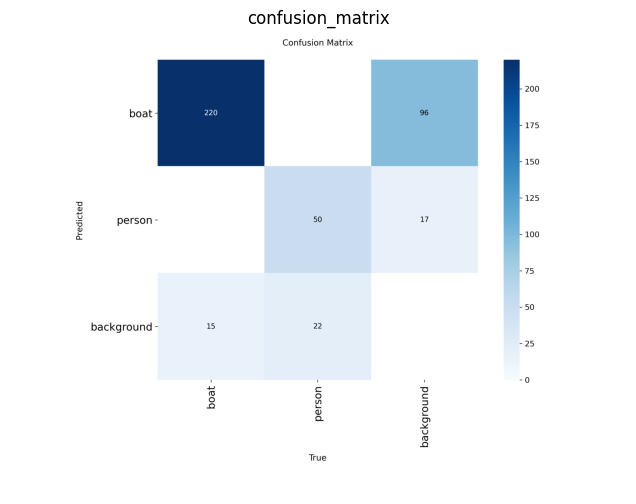

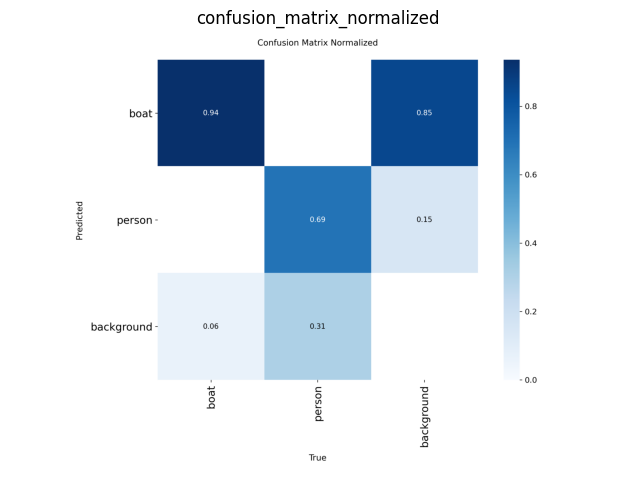

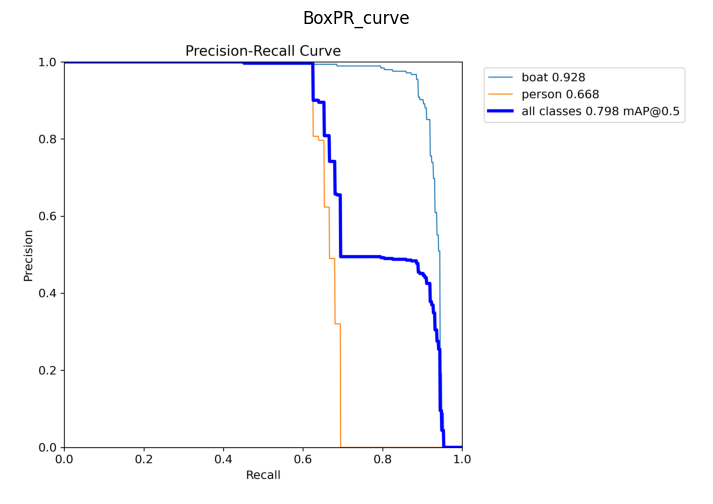

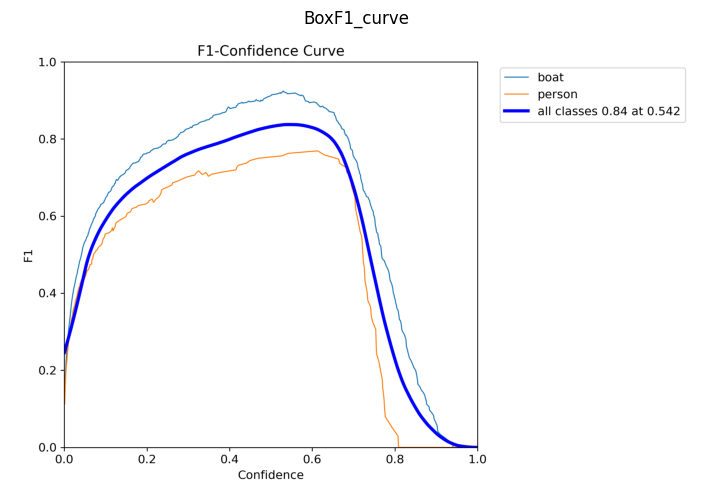

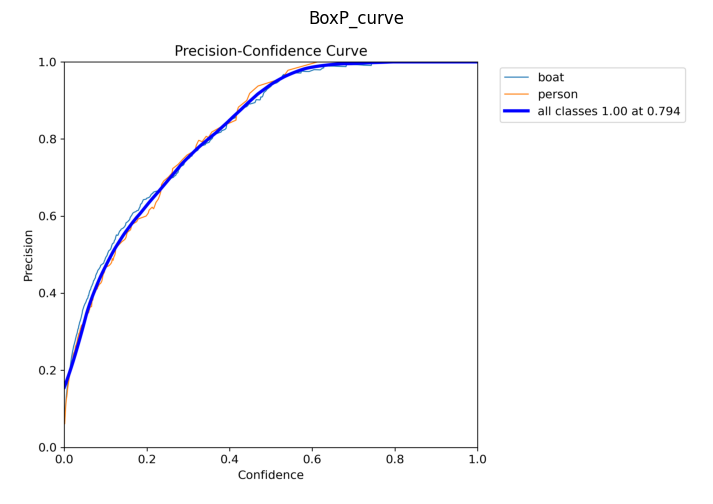

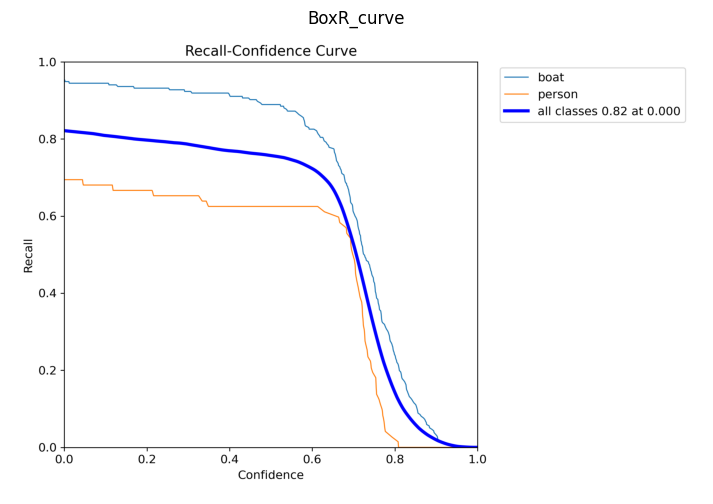

In [ ]:
TEST_BEST_DIR = RESULTS_DIR / "test_best_agroguard"

candidate_plots = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

found = []

for name in candidate_plots:
    path = TEST_BEST_DIR / name
    if path.exists():
        found.append(path)
        shutil.copy2(path, FIGURES_DIR / path.name)

print("Figuras encontradas:")
for path in found:
    print("-", path.name)

for path in found:
    image = plt.imread(path)
    plt.figure(figsize=(9, 6))
    plt.imshow(image)
    plt.title(path.stem)
    plt.axis("off")
    plt.show()


## 10. Comparación justa: YOLOv8n COCO vs YOLOv8n ajustado

La comparación utiliza exactamente las mismas imágenes de Test.

En COCO, `person` y `boat` usan identificadores de clase distintos a los IDs del dataset personalizado. Por ello, se crea una copia temporal de **las etiquetas de Test solamente** y se remapean los IDs por nombre de clase.

No se modifica el dataset original ni se utiliza Test durante el entrenamiento.


In [ ]:
BASELINE_EVAL_ROOT = Path("/content/agroguard_baseline_eval")
BASELINE_TEST_IMAGES = BASELINE_EVAL_ROOT / "test" / "images"
BASELINE_TEST_LABELS = BASELINE_EVAL_ROOT / "test" / "labels"

if BASELINE_EVAL_ROOT.exists():
    shutil.rmtree(BASELINE_EVAL_ROOT)

BASELINE_TEST_IMAGES.mkdir(parents=True, exist_ok=True)
BASELINE_TEST_LABELS.mkdir(parents=True, exist_ok=True)

baseline_model = YOLO("yolov8n.pt")
coco_names = {int(k): str(v) for k, v in baseline_model.names.items()}
coco_name_to_id = {name: cid for cid, name in coco_names.items()}

required_names = set(CLASS_NAMES.values())
missing_in_coco = required_names - set(coco_name_to_id)

if missing_in_coco:
    raise RuntimeError(
        "Estas clases del dataset AgroGuard no existen con el mismo nombre en COCO: "
        f"{missing_in_coco}"
    )

custom_to_coco = {
    custom_id: coco_name_to_id[class_name]
    for custom_id, class_name in CLASS_NAMES.items()
}

print("Mapeo AgroGuard -> COCO:", custom_to_coco)


Mapeo AgroGuard -> COCO: {0: 8, 1: 0}


In [ ]:
original_test_images = resolve_split_images(DATA_YAML, "test")

test_images = sorted(
    p for p in original_test_images.rglob("*")
    if p.suffix.lower() in IMAGE_EXTENSIONS
)

for img in test_images:
    shutil.copy2(img, BASELINE_TEST_IMAGES / img.name)

    src_label = corresponding_label_path(img)
    dst_label = BASELINE_TEST_LABELS / f"{img.stem}.txt"

    if not src_label.exists() or not src_label.read_text(encoding="utf-8").strip():
        dst_label.write_text("", encoding="utf-8")
        continue

    remapped_lines = []

    for line in src_label.read_text(encoding="utf-8").strip().splitlines():
        parts = line.split()
        custom_id = int(float(parts[0]))
        parts[0] = str(custom_to_coco[custom_id])
        remapped_lines.append(" ".join(parts))

    dst_label.write_text("\n".join(remapped_lines), encoding="utf-8")

BASELINE_YAML = BASELINE_EVAL_ROOT / "data_coco_mapped.yaml"

baseline_cfg = {
    "path": str(BASELINE_EVAL_ROOT),
    "train": "test/images",
    "val": "test/images",
    "test": "test/images",
    "names": coco_names,
}

with open(BASELINE_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(baseline_cfg, f, sort_keys=False, allow_unicode=True)

print("Dataset temporal baseline:", BASELINE_EVAL_ROOT)
print("Imágenes:", len(test_images))
print("YAML:", BASELINE_YAML)


Dataset temporal baseline: /content/agroguard_baseline_eval
Imágenes: 110
YAML: /content/agroguard_baseline_eval/data_coco_mapped.yaml


In [ ]:
COCO_CLASSES_OF_INTEREST = sorted(custom_to_coco.values())

baseline_metrics = baseline_model.val(
    data=str(BASELINE_YAML),
    split="test",
    classes=COCO_CLASSES_OF_INTEREST,
    imgsz=640,
    batch=16,
    device=DEVICE,
    plots=True,
    project=str(RESULTS_DIR),
    name="test_baseline_coco",
    exist_ok=True,
    verbose=True,
)

baseline_summary = pd.DataFrame(baseline_metrics.summary(decimals=5))

display(baseline_summary)

baseline_summary.to_csv(
    TABLES_DIR / "metricas_test_baseline_coco_por_clase.csv",
    index=False,
    encoding="utf-8-sig"
)


Ultralytics 8.4.117 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1516.3±587.3 MB/s, size: 44.9 KB)
val: Scanning /content/agroguard_baseline_eval/test/labels... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 2.1Kit/s 0.1s
val: New cache created: /content/agroguard_baseline_eval/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.2it/s 3.1s
                   all        110        307      0.459      0.507      0.412      0.147
                person         44         72      0.258       0.41      0.182     0.0777
                  boat         66        235      0.661      0.604      0.642      0.217
Speed: 5.0ms preprocess, 5.0ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/drive/MyDrive/AgroGuard_AI/resultad

,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
0,person,44,72,0.25770,0.40987,0.31644,0.18202,0.07770
1,boat,66,235,0.66056,0.60426,0.63116,0.64189,0.21725


## 11. Comparación cuantitativa entre modelos

La comparación debe interpretarse métrica por métrica:

- mayor **Precision**: menor proporción relativa de falsas detecciones;
- mayor **Recall**: menor proporción relativa de objetos omitidos;
- mayor **mAP50**: mejor desempeño a IoU 0.50;
- mayor **mAP50-95**: mejor desempeño bajo criterios de localización más estrictos.


In [ ]:
metric_columns = ["Box-P", "Box-R", "Box-F1", "mAP50", "mAP50-95"]

best_cmp = best_summary[["Class"] + metric_columns].copy()
best_cmp["Modelo"] = "Ajustado"

baseline_cmp = baseline_summary[["Class"] + metric_columns].copy()
baseline_cmp["Modelo"] = "COCO"

comparison_long = pd.concat([baseline_cmp, best_cmp], ignore_index=True)

display(comparison_long)

comparison_long.to_csv(
    TABLES_DIR / "comparacion_coco_vs_ajustado.csv",
    index=False,
    encoding="utf-8-sig"
)


,Class,Box-P,Box-R,Box-F1,mAP50,mAP50-95,Modelo
0,person,0.25770,0.40987,0.31644,0.18202,0.07770,COCO
1,boat,0.66056,0.60426,0.63116,0.64189,0.21725,COCO
2,boat,0.96741,0.87234,0.91742,0.92809,0.44865,Ajustado
3,person,0.97835,0.62500,0.76274,0.66824,0.34058,Ajustado


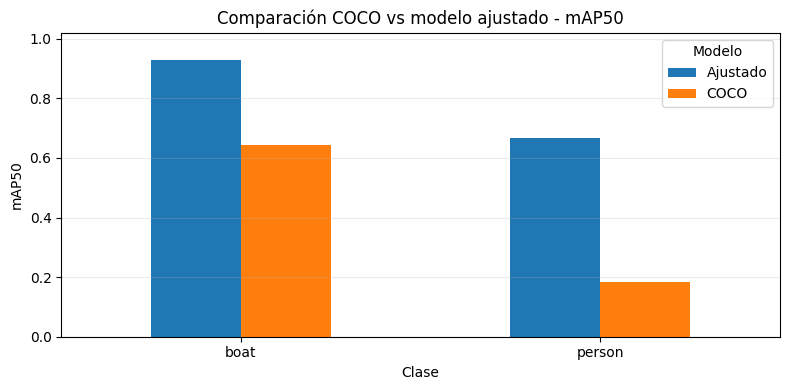

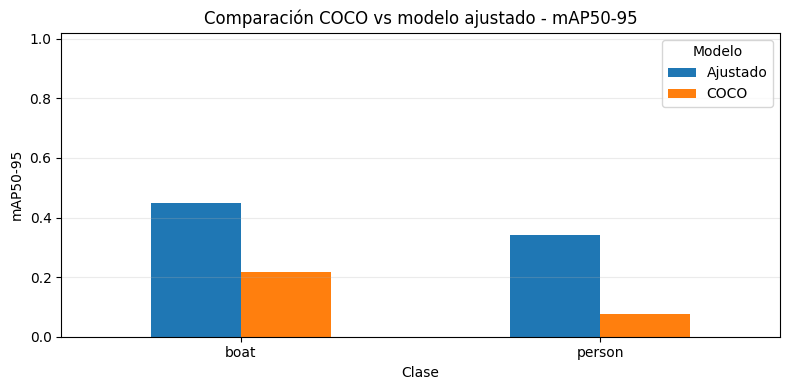

In [ ]:
for metric in ["mAP50", "mAP50-95"]:
    pivot = comparison_long.pivot(index="Class", columns="Modelo", values=metric)

    ax = pivot.plot(kind="bar", figsize=(8, 4))
    ax.set_title(f"Comparación COCO vs modelo ajustado - {metric}")
    ax.set_xlabel("Clase")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=0)
    plt.tight_layout()

    filename = f"05_comparacion_{metric.replace('-', '_')}.png"
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
base_indexed = baseline_cmp.set_index("Class")[metric_columns]
best_indexed = best_cmp.set_index("Class")[metric_columns]

common_classes = sorted(set(base_indexed.index) & set(best_indexed.index))

delta = best_indexed.loc[common_classes] - base_indexed.loc[common_classes]
delta.columns = [f"Delta_{c}" for c in delta.columns]
delta = delta.reset_index()

display(delta)

delta.to_csv(
    TABLES_DIR / "diferencias_ajustado_menos_coco.csv",
    index=False,
    encoding="utf-8-sig"
)


,Class,Delta_Box-P,Delta_Box-R,Delta_Box-F1,Delta_mAP50,Delta_mAP50-95
0,boat,0.30685,0.26808,0.28626,0.28620,0.23140
1,person,0.72065,0.21513,0.44630,0.48622,0.26288


## 12. Evidencia cualitativa sobre Test

Las métricas deben complementarse con ejemplos visuales de:

1. detecciones correctas;
2. falsos negativos;
3. falsos positivos;
4. objetos pequeños, lejanos u ocluidos.

Estas imágenes ayudan a explicar el comportamiento del detector, pero no sustituyen las métricas.


In [ ]:
PREDICTION_DIR = RESULTS_DIR / "predicciones_test"

prediction_results = best_model.predict(
    source=str(original_test_images),
    imgsz=640,
    conf=0.25,
    device=DEVICE,
    save=True,
    project=str(RESULTS_DIR),
    name="predicciones_test",
    exist_ok=True,
    verbose=False,
)

print("Predicciones guardadas en:", PREDICTION_DIR)


Results saved to /content/drive/MyDrive/AgroGuard_AI/resultados_yolov8n_v1/predicciones_test
Predicciones guardadas en: /content/drive/MyDrive/AgroGuard_AI/resultados_yolov8n_v1/predicciones_test


## 13. Resumen automático de resultados principales

Esta sección consolida los valores que posteriormente se utilizarán para redactar el capítulo de Resultados.


In [ ]:
print("=" * 70)
print("RESULTADOS PRINCIPALES - MODELO AJUSTADO")
print("=" * 70)

print(f"Precision media: {test_metrics.box.mp:.4f}")
print(f"Recall medio:    {test_metrics.box.mr:.4f}")
print(f"mAP50:           {test_metrics.box.map50:.4f}")
print(f"mAP50-95:        {test_metrics.box.map:.4f}")

print("\nMétricas por clase:")
display(best_summary)

print("\nDiferencia Ajustado - COCO:")
display(delta)

print("\nTiempo de inferencia reportado durante Test:")
print(test_metrics.speed)


RESULTADOS PRINCIPALES - MODELO AJUSTADO
Precision media: 0.9729
Recall medio:    0.7487
mAP50:           0.7982
mAP50-95:        0.3946

Métricas por clase:


,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
0,boat,66,235,0.96741,0.87234,0.91742,0.92809,0.44865
1,person,44,72,0.97835,0.62500,0.76274,0.66824,0.34058



Diferencia Ajustado - COCO:


,Class,Delta_Box-P,Delta_Box-R,Delta_Box-F1,Delta_mAP50,Delta_mAP50-95
0,boat,0.30685,0.26808,0.28626,0.28620,0.23140
1,person,0.72065,0.21513,0.44630,0.48622,0.26288



Tiempo de inferencia reportado durante Test:
{'preprocess': 3.2046078636292146, 'inference': 4.069441500004442, 'loss': 0.0007543454516549405, 'postprocess': 2.097081172727981}


## 14. Criterio para redactar la conclusión del objetivo

La evidencia de esta etapa permite responder:

> **¿El ajuste de YOLOv8n permite obtener un detector de `person` y `boat` con desempeño adecuado para continuar con la validación funcional de AgroGuard?**

La conclusión debe fundamentarse en:

1. métricas obtenidas sobre Test;
2. desempeño separado de `person` y `boat`;
3. comparación frente a YOLOv8n COCO sobre las mismas imágenes;
4. matriz de confusión y curvas PR/F1;
5. limitaciones observadas.

### Plantilla de interpretación

Completar únicamente después de ejecutar el notebook:

> El modelo YOLOv8n ajustado fue evaluado sobre un conjunto Test independiente compuesto por **[N] imágenes**. Se obtuvo una Precision media de **[P]**, un Recall de **[R]**, un mAP50 de **[M1]** y un mAP50-95 de **[M2]**. La clase `person` presentó **[describir]**, mientras que `boat` presentó **[describir]**. Frente al modelo YOLOv8n preentrenado en COCO, el ajuste produjo **[incremento/disminución]** principalmente en **[métrica/clase]**. Estos resultados **[respaldan/no respaldan todavía]** el uso del detector ajustado como componente de la prueba de concepto, dentro de las condiciones experimentales evaluadas.

No debe afirmarse que el modelo es válido para cualquier camaronera o condición ambiental a partir de este experimento.


## 15. Exportación del entregable

Se genera un ZIP con:

- `best.pt` y `last.pt`;
- tablas CSV;
- figuras para tesis;
- configuración del entorno;
- resultados de Test;
- comparación COCO vs modelo ajustado.


In [ ]:
weights_export = RESULTS_DIR / "pesos_finales"
weights_export.mkdir(parents=True, exist_ok=True)

shutil.copy2(BEST_MODEL, weights_export / "agroguard_yolov8n_best.pt")
shutil.copy2(LAST_MODEL, weights_export / "agroguard_yolov8n_last.pt")

ZIP_OUTPUT = DRIVE_ROOT / "AgroGuard_YOLOv8n_Resultados_V1"

archive_path = shutil.make_archive(
    str(ZIP_OUTPUT),
    "zip",
    root_dir=RESULTS_DIR
)

print("Entregable generado:")
print(archive_path)


Entregable generado:
/content/drive/MyDrive/AgroGuard_AI/AgroGuard_YOLOv8n_Resultados_V1.zip


# Referencias metodológicas y técnicas

- Ultralytics. **YOLO Model Training**. https://docs.ultralytics.com/modes/train/
- Ultralytics. **YOLO Model Validation**. https://docs.ultralytics.com/modes/val/
- Ultralytics. **YOLO Performance Metrics**. https://docs.ultralytics.com/guides/yolo-performance-metrics/
- T.-Y. Lin et al., **“Microsoft COCO: Common Objects in Context,”** *ECCV*, 2014. DOI: `10.1007/978-3-319-10602-1_48`.
- M. Sokolova and G. Lapalme, **“A systematic analysis of performance measures for classification tasks,”** *Information Processing & Management*, vol. 45, no. 4, 2009. DOI: `10.1016/j.ipm.2009.03.002`.

---

## Resultado esperado del notebook

Al finalizar se dispondrá de evidencia suficiente para documentar el ajuste del detector y evaluar cuantitativamente su desempeño. La validación funcional posterior de AgroGuard (reglas de amenaza, latencia extremo a extremo, actuación y almacenamiento de evidencias) corresponde a una fase experimental distinta.
